#**NLP PROJECT NWES CLASSIFICATION**

# Machine Learning

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import os
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
# Tread the data set
df=pd.read_csv("/content/News _Classification_Data.csv")
df.head()

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [ ]:
#dataset does not contain class labels, so we need to explicitly provide it
df = df.rename(columns={'Class Index':'label'})
df.head()

,label,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [ ]:
# explor the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   label        7600 non-null   int64 
 1   Title        7600 non-null   object
 2   Description  7600 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.3+ KB


/tmp/ipython-input-4114113357.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


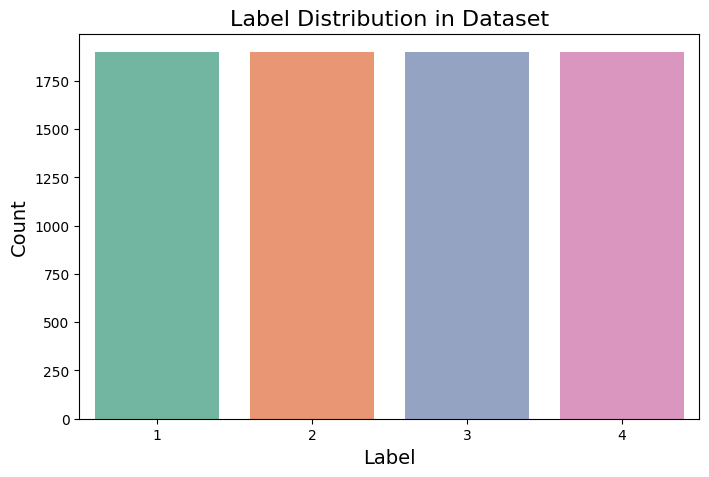

In [ ]:
# Visualize category distribution
plt.figure(figsize=(8,5))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Label Distribution in Dataset', fontsize=16)
plt.xlabel('Label', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.show()

In [ ]:
# concatinating the 'title' and 'description' column
df['text']=(df['Title']+df['Description'])
df.drop(columns=['Title','Description'],axis=1,inplace=True)
df.head()

,label,text
0,3,Fears for T N pension after talksUnions repres...
1,4,The Race is On: Second Private Team Sets Launc...
2,4,Ky. Company Wins Grant to Study Peptides (AP)A...
3,4,Prediction Unit Helps Forecast Wildfires (AP)A...
4,4,Calif. Aims to Limit Farm-Related Smog (AP)AP ...


# Data Preprocessing

In [ ]:
# Text before preprocessing - contains symbols like ()\-,.' which is not useful
df['text'][1]

'The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com)SPACE.com - TORONTO, Canada -- A second\\team of rocketeers competing for the  #36;10 million Ansari X Prize, a contest for\\privately funded suborbital space flight, has officially announced the first\\launch date for its manned rocket.'

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                                # lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # remove links
    text = re.sub(r'\d+', '', text)                     # remove numbers
    text = re.sub(r'[^\w\s]', '', text)                 # remove punctuation
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text

# the class label in dataset contains labels as 1,2,3,4 but the model needs 0,1,2,3, so we subtract 1 from all
df['label']=df['label'].apply(lambda x:x-1)

df['clean_text'] = df['text'].apply(clean_text)
print(df['clean_text'].head())

0    fears n pension talksunions representing worke...
1    race second private team sets launch date huma...
2    ky company wins grant study peptides apap comp...
3    prediction unit helps forecast wildfires apap ...
4    calif aims limit farmrelated smog apap souther...
Name: clean_text, dtype: object


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#Machine Learning Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#Split the data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(df['clean_text'], df['label'], test_size=0.2, random_state=42)

In [ ]:
#Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Train Naive Bayes classifier
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)


 Naive Bayes Accuracy: 0.8763
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       373
           1       0.93      0.96      0.95       389
           2       0.82      0.86      0.84       359
           3       0.89      0.79      0.84       399

    accuracy                           0.88      1520
   macro avg       0.88      0.88      0.88      1520
weighted avg       0.88      0.88      0.88      1520



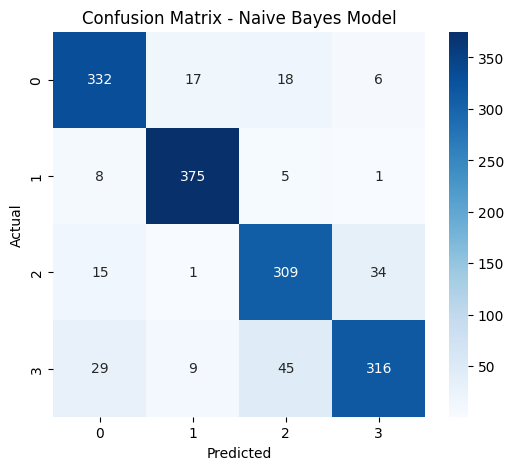

In [ ]:
# Evaluatation of the model
nb_acc = accuracy_score(y_test, nb_preds)
print(f"\n Naive Bayes Accuracy: {nb_acc:.4f}")
print(classification_report(y_test, nb_preds))

# Confusion Matrix visualization for the model
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# LLMs

In [ ]:
# Libraries for BERT
import torch
from transformers import BertTokenizerFast, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

In [ ]:
# Split the data again for BERT
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
# Tokenization
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(examples['clean_text'], padding="max_length", truncation=True)

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Map:   0%|          | 0/6080 [00:00<?, ? examples/s]

Map:   0%|          | 0/1520 [00:00<?, ? examples/s]

In [ ]:
# Load and Train the BERT model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(df['label'].unique())
)

# Training setup
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    optim="adamw_torch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8, # Added for evaluation batch size
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10
)

# Trainer configuration
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer
)

trainer.train()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-214014006.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nouraalhuthli76 (nouraalhuthli76-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,0.329900,0.389259
2,0.093600,0.395821
3,0.370200,0.479742
4,0.090600,0.497955
5,0.123000,0.506731


TrainOutput(global_step=3800, training_loss=0.23816141833796312, metrics={'train_runtime': 3171.0762, 'train_samples_per_second': 9.587, 'train_steps_per_second': 1.198, 'total_flos': 7998719714918400.0, 'train_loss': 0.23816141833796312, 'epoch': 5.0})

In [ ]:
# Make predictions with BERT
preds = trainer.predict(tokenized_test)
pred_labels = np.argmax(preds.predictions, axis=1)
true_labels = test_df['label'].values


 BERT Accuracy: 0.9039
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       373
           1       0.97      0.98      0.98       389
           2       0.84      0.86      0.85       359
           3       0.89      0.86      0.88       399

    accuracy                           0.90      1520
   macro avg       0.90      0.90      0.90      1520
weighted avg       0.90      0.90      0.90      1520



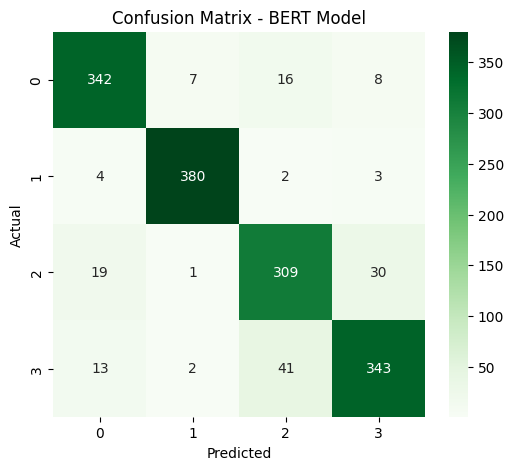

In [ ]:
# Evaluatation of the model
bert_acc = accuracy_score(true_labels, pred_labels)
print(f"\n BERT Accuracy: {bert_acc:.4f}")
print(classification_report(true_labels, pred_labels))

# Confusion matrix for BERT
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(true_labels, pred_labels), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - BERT Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

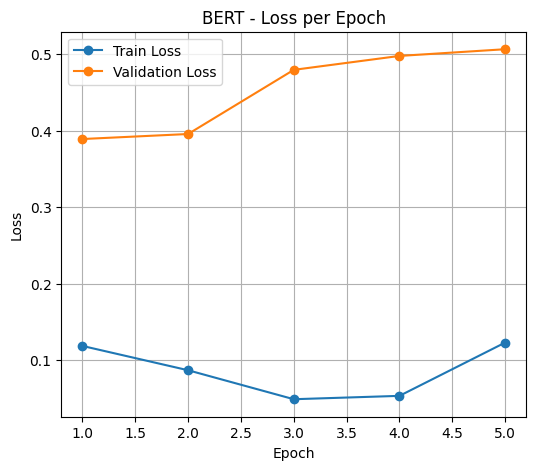

In [ ]:
# Extract metrics from trainer logs
# Filter logs to get loss at the end of each epoch
bert_train_loss = [log['loss'] for log in trainer.state.log_history if 'loss' in log and 'learning_rate' in log]
bert_val_loss = [log['eval_loss'] for log in trainer.state.log_history if 'eval_loss' in log]

# Ensure the lengths match for plotting, assuming eval_loss is logged once per epoch
# If lengths still don't match, further inspection of log_history would be needed
if len(bert_train_loss) > len(bert_val_loss):
  # This might happen if training loss is logged more frequently than eval loss
  # For this plot, we align based on the number of evaluation points
  bert_train_loss = bert_train_loss[-len(bert_val_loss):]


epochs = range(1, len(bert_val_loss) + 1) # Use the length of validation loss to define epochs

plt.figure(figsize=(6, 5))
plt.plot(epochs, bert_train_loss, label='Train Loss', marker='o')
plt.plot(epochs, bert_val_loss, label='Validation Loss', marker='o')
plt.title('BERT - Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# save the model
trainer.save_model("models")
tokenizer.save_pretrained("models")

('models/tokenizer_config.json',
 'models/special_tokens_map.json',
 'models/vocab.txt',
 'models/added_tokens.json',
 'models/tokenizer.json')

# Visualization and Comparasion of the models

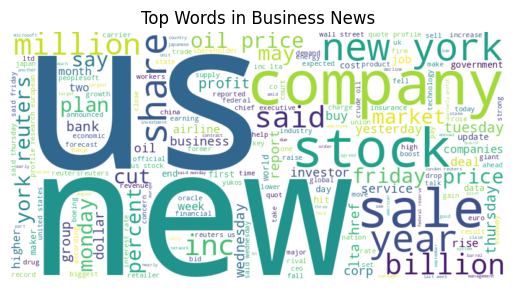

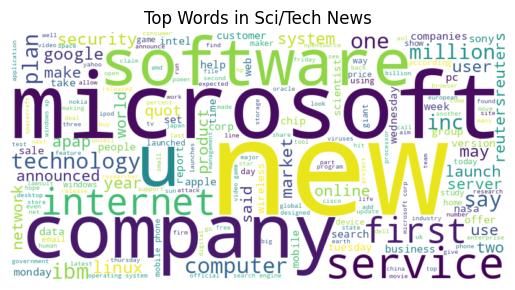

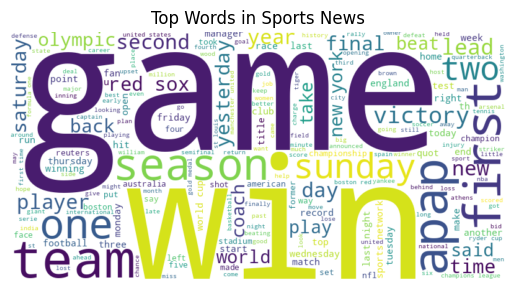

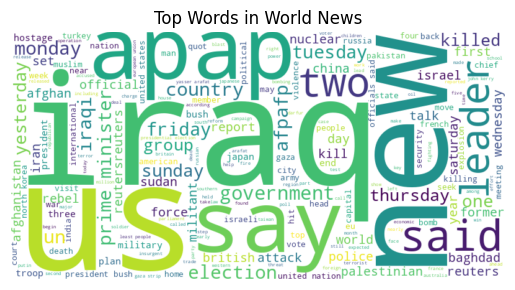

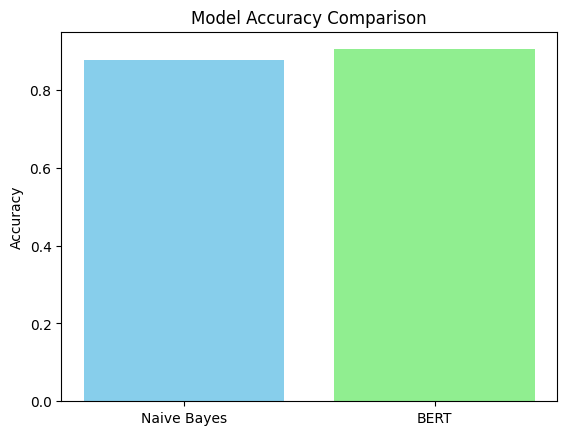

In [ ]:
from wordcloud import WordCloud

label2category = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}
df['category'] = df['label'].map(label2category)

# 🟣 WordCloud for each category
for category in df['category'].unique():
    text = " ".join(df[df['category']==category]['clean_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Top Words in {category} News")
    plt.show()

# 🟢 Compare Model Accuracy
plt.bar(["Naive Bayes", "BERT"], [nb_acc, bert_acc], color=['skyblue', 'lightgreen'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# save the model to create streamlit

In [ ]:
from google.colab import files
import shutil
shutil.make_archive('models', 'zip', 'models')
files.download('models.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>